Load and prepare data into a dataframe

In [3]:
import pandas as pd

df = pd.read_csv("data/train.csv")

df["Year_Num"] = df["Year"].str.replace("x", "0").astype(int)

df_sorted = df.sort_values(by=["ID", "Year_Num"])

df_model_next = df_sorted.dropna(subset=["Ladder_Position_Next"])


select features that can be used and change data values to a more usable form

In [4]:
from sklearn.impute import SimpleImputer

features = [
    "Games_Won", "Games_Lost", "Games_Drawn", "Points_For", "Points_Against",
    "Percentage", "Ladder_Position", "Average_Age", "Ladder_Position_Prev",
    "Close_Games_Won", "Close_Games_Lost", "Away_Games_Won", "Last_Five",
    "Average_Attendance", "Players_Used", "Victorian"
]

X = df_model_next[features].copy()
X["Victorian"] = X["Victorian"].astype(int)
y = df_model_next["Ladder_Position_Next"]

imputer = SimpleImputer(strategy="mean")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

model training

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

find MAE and visualise the most important features for predictions

Mean Absolute Error (Ladder Position): 2.75


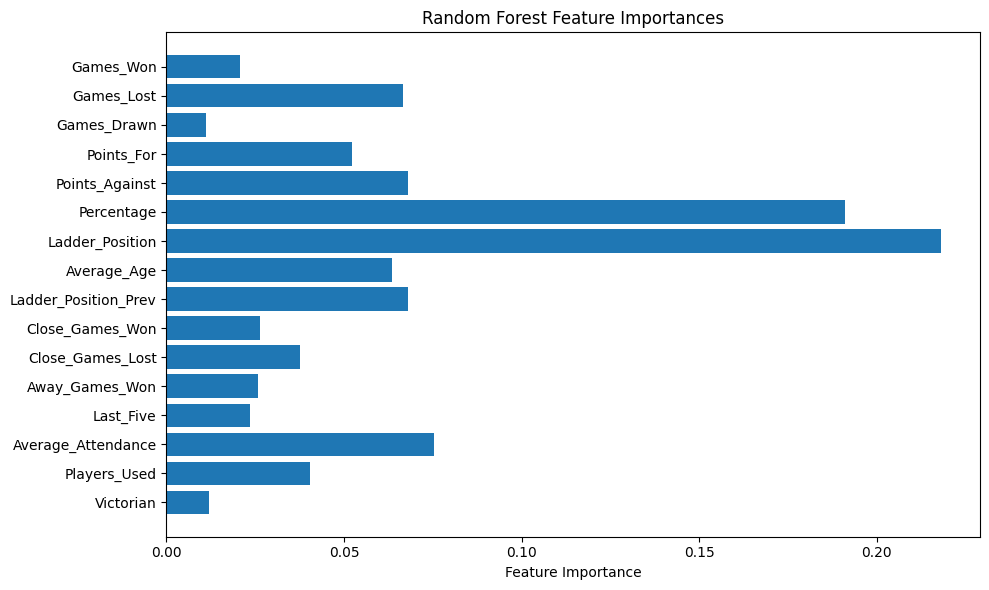

In [6]:
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error (Ladder Position): {mae:.2f}")

importances = model.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(X.columns, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

This supports our findings from the linear regression, as the intercept of 2.69 is very close to the MAE of 2.75, which supports the idea that ladder position previous can be used as a way to predict future rankings, however, we find also that the percentage is a very good indication of how a team would be performing in the following years.